# Zero-Copy RAG - Interactive Demo

**The Zero-Copy RAG (Retrieval-Augmented Generation)** is an architectural solution that allows organizations to analyze unstructured data, such as PDFs and text files, without moving it from its original storage silos (like Google Cloud Storage). Instead of copying data to external vector databases, this approach brings the AI directly to the data.

It achieves this by exposing files stored in Google Cloud Storage to BigQuery using **Object Tables**. From there, the architecture natively leverages built-in functions—like Document AI and the Gemini Enterprise Platform—to extract text, generate vector embeddings, and perform semantic searches natively within the data warehouse.

**Key benefits of the Zero-Copy RAG architecture include:**
- **No Data Integration Overhead:** It bypasses the traditional "ETL tax" and complex external infrastructure by executing real-time decision-making and machine learning natively in-place.
- **Enhanced Security:** Sensitive documents never leave the boundaries of Google Cloud Storage and BigQuery, which minimizes overall security risks.
- **Unified Workspace:** Data teams can seamlessly toggle between Python and SQL within a single environment, avoiding the overhead of provisioning separate compute clusters.
- **Real-Time Intelligence:** By eliminating the need to build agents on isolated, copied datasets, the system minimizes latency and ensures that models always act on the freshest data.

**How this relates to Clinical Trials Analytics:**
The Clinical Trials Analytics Demo is an industry-specific instance of the "Zero-Copy RAG" architecture. It proves the primary goal of the Zero-Copy RAG solution: it eliminates the need to move enterprise data between silos by executing analytics and AI on unstructured data in-place using BigQuery Object Tables.

In the healthcare context, this means that highly sensitive trial documents never leave the Google Cloud Storage and BigQuery boundaries, minimizing security risks and latency. The Zero-Copy RAG solution promises the rapid, secure deployment of generative AI agents without data integration overhead, and this clinical trials notebook is the physical proof of that capability applied to healthcare. It transforms static Clinical Study Summary Reports into a rich, queryable knowledge graph entirely through SQL and native BigQuery AI functions.

This notebook demonstrates the full capabilities of the **R&D Data Research Platform** built on BigQuery.

> [!NOTE]
> 🔬 **The documents explored in this notebook are all synthetically generated.** If you would you like to generate your own synthetic documents you can use these files as guidance. You can explore these documents in the [INSTALLATION.md](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery/blob/main/INSTALLATION.md) and [README.md](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery/blob/main/README.md) in the [document-analytics-on-bigquery](https://github.com/GoogleCloudPlatform/document-analytics-on-bigquery) repository.

## 🎯 Key Capabilities

1. **Generative AI** - LLM-powered summaries (Gemini 2.5 Pro)
2. **Semantic Search** - Vector similarity using 768-dimensional embeddings
3. **Graph Traversal** - Multi-hop pattern matching using GQL (GRAPH_TABLE)
4. **Relational SQL** - Traditional analytics and aggregations


## 🎯 Data Statistics

**8 Node Types:**
- 🧪 **Trial** - 1,200 clinical trials with 768-dim semantic embeddings
- 💊 **Drug** - Pharmaceutical compounds (UMLS CUIs)
- 🩺 **Disorder** - Medical conditions with SNOMED CT hierarchy + embeddings (1,657 disorders)
- 🔬 **MOA** - Mechanisms of Action (536 mechanisms)
- 📋 **TrialCriteria** - Requirements (17 criteria: disease indications, phase, status)
- 🏢 **Company** - Pharmaceutical manufacturers
- 🔢 **Phase** - Trial phases (9: Early Phase 1, Phase 1, 1/2, 2, 2/3, 3, 4, N/A)
- ✅ **Status** - Trial status (8: Recruiting, Active, Completed, Terminated, etc.)

**9 Edge Types:**
- Drug → Disorder (MayTreat): 8,405 relationships
- Disorder → Disorder (IsSubtypeOf): 1,701 SNOMED hierarchy relationships
- Trial → Phase (InPhase): 1,200 relationships
- Trial → Status (HasStatus): 1,200 relationships
- Trial → Criteria (Requires): 2,400 relationships
- Drug → MOA (HasMechanismOfAction)
- Drug → Company (ManufacturedBy): 2 relationships
- Trial → Drug (Uses)
- Trial → Disorder (Treats)

In [ ]:
#@title Configuration Form { display-mode: "form" }

PROJECT_ID = "meridian-dev-455515" #@param {type:"string"}

DATASET_ID = "joe_demo_test" #@param {type:"string"}

BUCKET_NAME = "cssr_reports_trials" #@param {type:"string"}

FOLDER_NAME = "april2_generation" #@param {type:"string"}

CONNECTION_ID = "meridian-dev-455515.us.cloud_ai_resources" #@param {type:"string"}

TABLE_NAME = "ClinicalTrialMasterData_embedded2" #@param {type:"string"}

TABLE_2_NAME = "ClinicalTrialChunks" #@param {type:"string"}

GRAPH_NAME = "clinical_trial_graph" #@param {type:"string"}

VECTOR_INDEX_NAME = "clinical_trial_vector_index" #@param {type:"string"}

# Set environment variable for BigQuery and other clients
import os
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID

# Try to set BigFrames project if available
try:
    import bigframes
    bigframes.options.bigquery.project = PROJECT_ID
    print(f"BigFrames project set to: {PROJECT_ID}")
except ImportError:
    pass

print(f"Configuration loaded for project: {PROJECT_ID}")

BigFrames project set to: meridian-dev-455515
Configuration loaded for project: meridian-dev-455515


# Clinical Trials Analytics Demo
This notebook demonstrates an end-to-end clinical trials analytics workflow in BigQuery, leveraging unstructured data from GCS, autonomous embeddings, semantic search, and graph analysis.

In [ ]:
import subprocess
import sys
from IPython import get_ipython

# Install dependencies
packages = [
    "google-cloud-bigquery",
    "google-cloud-bigquery-storage",
    "google-cloud-storage",
    "pandas",
    "db-dtypes",
    "pdf2image",
    "bigquery-magics[spanner-graph-notebook]"
]

# Use extra-index-url to fallback to public PyPI for packages not found in internal index
subprocess.check_call([sys.executable, "-m", "pip", "install", "--extra-index-url", "https://pypi.org/simple/"] + packages)

# Load the extension
get_ipython().run_line_magic('load_ext', 'google.cloud.bigquery')

# Authenticate user for GCP access
from google.colab import auth
print("Please authenticate to access GCP resources:")
auth.authenticate_user()

The google.cloud.bigquery extension is already loaded. To reload it, use:
  %reload_ext google.cloud.bigquery
Please authenticate to access GCP resources:


## Step 0: Documents in GCS
We list the files in the GCS bucket and preview the text content of the first document to understand the data we are working with.

Listing files in GCS bucket: cssr_reports_trials/april2_generation...
Rendering first 2 pages...



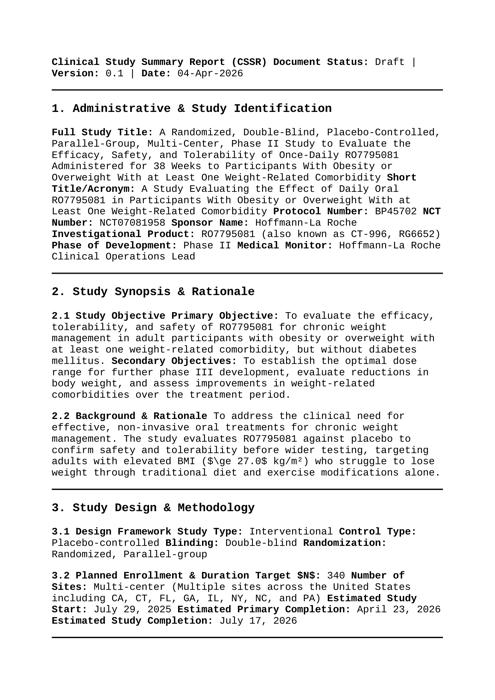
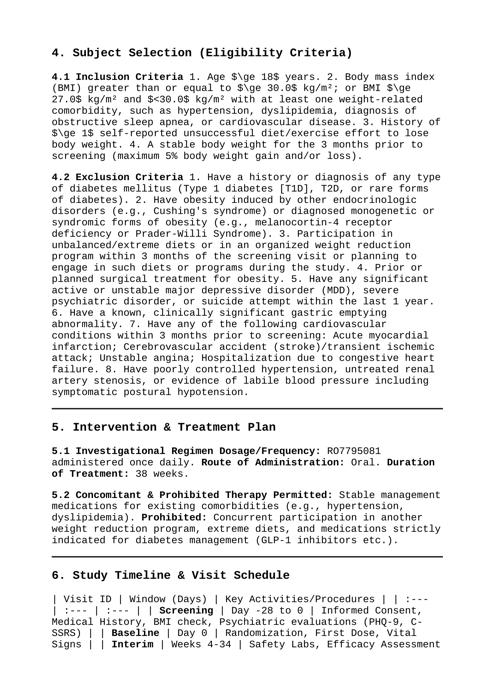

In [ ]:
import subprocess
import sys
from IPython.display import display, HTML
import io
import base64

# 1. Install dependencies for visual rendering
try:
    subprocess.check_call(["apt-get", "install", "poppler-utils", "-y", "-q"])
except Exception as e:
    print(f"Could not install poppler-utils via apt-get: {e}")

subprocess.check_call([sys.executable, "-m", "pip", "install", "pdf2image"])

from pdf2image import convert_from_path

# 2. List and download a sample PDF from GCS
# Use BUCKET_NAME and FOLDER_NAME from the form
bucket = globals().get('BUCKET_NAME', 'cssr_reports_trials')
folder = globals().get('FOLDER_NAME', 'april2_generation')
print(f"Listing files in GCS bucket: {bucket}/{folder}...")

try:
    files = subprocess.check_output(["gsutil", "ls", f"gs://{bucket}/{folder}/*.pdf"]).decode('utf-8').splitlines()

    if files:
        sample_pdf = files[0]
        print(f"Downloading sample PDF: {sample_pdf}")
        subprocess.check_call(["gsutil", "cp", sample_pdf, "sample.pdf"])

        # 3. Render 2 pages and display side-by-side
        print("Rendering first 2 pages...")
        images = convert_from_path('sample.pdf', first_page=1, last_page=2)

        # Convert images to base64 for HTML display
        html_content = "<div style='display: flex; justify-content: space-around; flex-wrap: wrap;'>"
        for i, img in enumerate(images):
            img.thumbnail((500, 700)) # Make larger
            buffered = io.BytesIO()
            img.save(buffered, format="JPEG")
            img_str = base64.b64encode(buffered.getvalue()).decode()
            html_content += f"""
            <div style='margin: 10px; text-align: center;'>
                <p style='font-weight: bold;'>Page {i+1}</p>
                <img src='data:image/jpeg;base64,{img_str}' style='border: 1px solid #ccc; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);' />
            </div>
            """
        html_content += "</div>"

        display(HTML(html_content))
    else:
        print(f"No PDF files found in gs://{bucket}/{folder}/")
except Exception as e:
    print(f"Error exploring PDFs: {e}")

## Step 1: Generate Object Table (Ingesting Data In-Place)
The Zero-Copy RAG architecture relies on exposing files stored in Google Cloud Storage to BigQuery via Object Tables. We create an external object table in BigQuery to reference the raw documents stored in GCS (`gs://{BUCKET_NAME}/{FOLDER_NAME}/*`), demonstrating ingesting unstructured data in-place without moving it.

See the [Object Tables Documentation](https://cloud.google.com/bigquery/docs/object-tables) for more details.

In [ ]:
# sql_engine: bigquery
# output_variable: object_table
# start _sql
_sql = """
CREATE EXTERNAL TABLE IF NOT EXISTS `{PROJECT_ID}.{DATASET_ID}.object_table`
WITH CONNECTION `{CONNECTION_ID}`
OPTIONS (
  object_metadata = 'DIRECTORY',
  uris = ['gs://{BUCKET_NAME}/{FOLDER_NAME}/*']
  );
""" # end _sql

import bigframes.pandas as bpd

# Close any existing BigFrames session. This is important in Colab because 
# if you run this cell a second time, the session will already exist, 
# and the application_name cannot be changed once a session has started.
bpd.close_session()

# Set the application_name (this is passed as the user_agent to ClientInfo under the hood)
bpd.options.bigquery.application_name = "cloud-solutions/data-to-ai-nb-v2"

from google.colab.sql import bigquery as _bqsqlcell
object_table = _bqsqlcell.run(_sql)
object_table

,statement_type,job_id,location
0,CREATE_EXTERNAL_TABLE,job_67k2O-m6m_uYSiTik20O02Ivglp6,US


## Step 2: Define Full Schema with Autonomous Embeddings (Native Embeddings & Text Extraction)
A core feature of Zero-Copy RAG is that it leverages built-in functions like Document AI and Gemini to extract text and generate vector embeddings natively within the data warehouse.

Here, we define the full table schema with all required columns and explicitly demonstrate this capability by configuring an autonomous embedding column (`ClinicalTrialMasterData_embedded`) using `AI.EMBED` directly in the schema definition for the `StudyTitle`. This table will be populated in the next step.

See the [Autonomous Embedding Generation Documentation](https://docs.cloud.google.com/bigquery/docs/autonomous-embedding-generation) for more details.

In [ ]:
# sql_engine: bigquery
# output_variable: ClinicalTrialMasterData_embedded
# start _sql
_sql = """
CREATE TABLE IF NOT EXISTS `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` (
  uri STRING,
  Sponsor STRING,
  StudyTitle STRING,
  PreferredUMLSName ARRAY<STRING>,
  NCT_Number STRING,
  Phase STRING,
  Trial_Status STRING,
  Disease_Areas STRING,
  Targeted_Enrollment INT64,
  Company STRING,
  semantic_text STRING,
  name STRING,
  preferred_name STRING,
  semantic_type ARRAY<STRING>,
  definition STRING,
  mesh_code STRING,
  mesh_codes ARRAY<STRING>,
  hpo_codes ARRAY<STRING>,
  snomed_id STRING,
  snomed_hierarchy ARRAY<STRING>,
  drug_name STRING,
  atc_code STRING,
  atc_codes ARRAY<STRING>,
  rxnorm_code STRING,
  trade_names ARRAY<STRING>,
  ema_url ARRAY<STRING>,
  source_level INT64,
  drug_preferred_name STRING,
  drug_semantic_type ARRAY<STRING>,
  criteria_type STRING,
  criteria_text STRING,
  phase_id STRING,
  status_name STRING,
  status_description STRING,
  objectRef STRING,
  ClinicalTrialMasterData_embedded STRUCT<result ARRAY<FLOAT64>, status STRING>
    GENERATED ALWAYS AS (AI.EMBED(
      StudyTitle,
      connection_id => '{CONNECTION_ID}',
      endpoint => 'text-embedding-005'
    ))
    STORED
    OPTIONS( asynchronous = TRUE )
);
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
ClinicalTrialMasterData_embedded = _bqsqlcell.run(_sql)
ClinicalTrialMasterData_embedded

,statement_type,job_id,location
0,CREATE_TABLE,job_DKsOuyEIfyF9TTqPmAiYltAjc6iu,US


## Step 3: Populate Full Table using AI.GENERATE (Text Extraction)
Continuing with the native capabilities of Zero-Copy RAG, we use the `AI.GENERATE` function, calling the `gemini-2.5-flash` model via SQL, to instantly parse and extract complex fields (like Sponsor, Trial Status, and Disease Areas) from the raw PDF documents.

This populates the table created in Step 2 with structured data extracted directly from the unstructured files in GCS.

See the [AI.GENERATE Documentation](https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-ai-generate) for more details on using LLMs in BigQuery.

In [ ]:
# sql_engine: bigquery
# output_variable: ClinicalTrialMasterData_embedded
# start _sql
_sql = """
-- Check if table is empty before inserting
IF NOT EXISTS (SELECT 1 FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` LIMIT 1) THEN
  INSERT INTO `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
  (uri, Sponsor, StudyTitle, PreferredUMLSName, NCT_Number, Phase, Trial_Status, Disease_Areas, Targeted_Enrollment, Company, semantic_text, name, preferred_name, semantic_type, definition, mesh_code, mesh_codes, hpo_codes, snomed_id, snomed_hierarchy, drug_name, atc_code, atc_codes, rxnorm_code, trade_names, ema_url, source_level, drug_preferred_name, drug_semantic_type, criteria_type, criteria_text, phase_id, status_name, status_description, objectRef)
  SELECT
    uri, Sponsor, StudyTitle, PreferredUMLSName, NCT_Number, Phase, Trial_Status, Disease_Areas, Targeted_Enrollment, Company, semantic_text, name, preferred_name, semantic_type, definition, mesh_code, mesh_codes, hpo_codes, snomed_id, snomed_hierarchy, drug_name, atc_code, atc_codes, rxnorm_code, trade_names, ema_url, source_level, drug_preferred_name, drug_semantic_type, criteria_type, criteria_text, phase_id, status_name, status_description,
    uri AS objectRef
  FROM (
    SELECT
      uri,
      AI.GENERATE(
        prompt => STRUCT('Extract the following fields from the clinical trial document: Sponsor, StudyTitle, PreferredUMLSName (as array), NCT_Number, Phase, Trial_Status, Disease_Areas, Targeted_Enrollment (as integer), Company, semantic_text, name, preferred_name, semantic_type (as array), definition, mesh_code, mesh_codes (as array), hpo_codes (as array), snomed_id, snomed_hierarchy (as array), drug_name, atc_code, atc_codes (as array), rxnorm_code, trade_names (as array), ema_url (as array), source_level (as integer), drug_preferred_name, drug_semantic_type (as array), criteria_type, criteria_text, phase_id, status_name, status_description.', OBJ.GET_ACCESS_URL(OBJ.MAKE_REF(uri, '{CONNECTION_ID}'), 'r')),
        endpoint => 'gemini-2.5-flash',
        output_schema => 'Sponsor STRING, StudyTitle STRING, PreferredUMLSName ARRAY<STRING>, NCT_Number STRING, Phase STRING, Trial_Status STRING, Disease_Areas STRING, Targeted_Enrollment INT64, Company STRING, semantic_text STRING, name STRING, preferred_name STRING, semantic_type ARRAY<STRING>, definition STRING, mesh_code STRING, mesh_codes ARRAY<STRING>, hpo_codes ARRAY<STRING>, snomed_id STRING, snomed_hierarchy ARRAY<STRING>, drug_name STRING, atc_code STRING, atc_codes ARRAY<STRING>, rxnorm_code STRING, trade_names ARRAY<STRING>, ema_url ARRAY<STRING>, source_level INT64, drug_preferred_name STRING, drug_semantic_type ARRAY<STRING>, criteria_type STRING, criteria_text STRING, phase_id STRING, status_name STRING, status_description STRING',
        connection_id => '{CONNECTION_ID}'
      ).* EXCEPT (full_response, status)
    FROM
      `{PROJECT_ID}.{DATASET_ID}.object_table`
  );
  SELECT 'Data inserted successfully.' AS status;
ELSE
  SELECT 'Table is not empty. Skipping insertion.' AS status;
END IF;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
ClinicalTrialMasterData_embedded = _bqsqlcell.run(_sql)
ClinicalTrialMasterData_embedded

Previewing the tables



In [ ]:
# sql_engine: bigquery
# output_variable: preview_df
# start _sql
_sql = f"""
SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` LIMIT 5;
""" # end _sql

import bigframes.pandas as bpd

# Close any existing BigFrames session. This is important in Colab because 
# if you run this cell a second time, the session will already exist, 
# and the application_name cannot be changed once a session has started.
bpd.close_session()

# Set the application_name (this is passed as the user_agent to ClientInfo under the hood)
bpd.options.bigquery.application_name = "cloud-solutions/data-to-ai-nb-v2"

from google.colab.sql import bigquery as _bqsqlcell
preview_df = _bqsqlcell.run(_sql)

# Convert to regular Pandas DataFrame to avoid BigFrames apply error
preview_df = preview_df.to_pandas()

# Trim embeddings for readability
if 'ClinicalTrialMasterData_embedded' in preview_df.columns:
    preview_df['ClinicalTrialMasterData_embedded'] = preview_df['ClinicalTrialMasterData_embedded'].apply(
        lambda x: {'result': list(x['result'][:3]) + ['...'], 'status': x.get('status')} if isinstance(x, dict) and 'result' in x else x
    )

preview_df


## Step 4: AI.Search (Semantic Search without Vector Databases)
Finally, Zero-Copy RAG eliminates the need for external vector databases to perform semantic and hybrid search.

In this step, this is proven by using the native `AI.SEARCH` function in BigQuery to run pure semantic searches on the embeddings we generated, right alongside traditional SQL filters. This allows us to perform vector similarity searches without ever leaving the data warehouse.

**What it is and why it's useful:**
`AI.SEARCH` enables semantic and hybrid search directly within BigQuery. Instead of moving data to a specialized vector database, you can compute vector similarity and combine it with standard SQL filters, joins, and aggregations in a single query. This simplifies architecture and leverages BigQuery's scale for complex analytics on unstructured data.

See the [AI.SEARCH Documentation](https://docs.cloud.google.com/bigquery/docs/reference/standard-sql/bigqueryml-syntax-ai-search?hl=en) for more details.

In [ ]:
# sql_engine: bigquery
# output_variable: top_5_cancer
# start _sql
_sql = """
SELECT
  base.StudyTitle,
  distance
FROM AI.SEARCH(
  TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`,
  'StudyTitle',
  'Cancer treated by MK-3475',
  top_k => 10
)
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
top_5_cancer = _bqsqlcell.run(_sql)
top_5_cancer

,StudyTitle,distance
0,Study of MK-4830 as Monotherapy and in Combina...,0.803099
1,"A Phase 3, Randomized, Open-label, Multicenter...",0.813753
2,Long-term Safety and Efficacy Extension Study ...,0.820765
3,Study of Pembrolizumab (MK-3475) in Participan...,0.8216
4,"A Phase 1/1b Open-label, Multicenter Clinical ...",0.827087
5,"A Phase 1 Open-label, Multicenter Study of MK-...",0.838582
6,Phase Ib/II Trial of Pembrolizumab (MK-3475) C...,0.839583
7,Study of MK-4464 as Monotherapy and in Combina...,0.841923
8,A Study of Investigational Agents in Participa...,0.844098
9,Study of Ulevostinag (MK-1454) Alone or in Com...,0.846828


### Advanced Hybrid Search: Native HYBRID Mode
In this example, we show how combining lexical (keyword) search with semantic search can improve results using the native `HYBRID` mode in `AI.SEARCH`. Pure semantic search might return documents that are conceptually similar but miss specific keyword matches (like specific drug names or trial IDs) that are critical.

Here we search for trials related to "immunotherapy" but also want to ensure we match the specific drug "Keytruda". We pass both terms in the query and set `mode => 'hybrid'`. This combines the power of vector search with keyword matching without needing complex regex filters.

> [!IMPORTANT]
> Hybrid search in `AI.SEARCH` is still in preview and requires an allowlist as of April 21st, 2026.

In [ ]:
# sql_engine: bigquery
# output_variable: hybrid
# start _sql
_sql = """
SELECT
  base.StudyTitle
FROM AI.SEARCH(
  TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`,
  'StudyTitle',
  'Cancer treated by MK-3475',
  mode => 'hybrid',
  top_k => 10
)
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
hybrid = _bqsqlcell.run(_sql)
hybrid

,StudyTitle
0,A Study of Investigational Agents in Participa...
1,Phase Ib/II Trial of Pembrolizumab (MK-3475) C...
2,Study of Pembrolizumab (MK-3475) in Participan...
3,Study of MK-4830 as Monotherapy and in Combina...
4,Study of Pembrolizumab (MK-3475) vs Placebo fo...
5,Efficacy and Safety of Pembrolizumab (MK-3475)...
6,Study of Pembrolizumab (MK-3475) and Pembroliz...
7,Substudy 011: A Study of Investigational Agent...
8,Safety and Efficacy Study of Investigational A...
9,Study of Ulevostinag (MK-1454) Alone or in Com...


## Step 5: [Optional] Parse Documents using AI.PARSE_DOCUMENT
We use `AI.PARSE_DOCUMENT` to extract content from documents in GCS. This step is optional and demonstrates document parsing capabilities. This is "nifty" because it can handle complex layouts, tables, and formatting much better than traditional OCR, and it returns structured chunks.

> [!IMPORTANT]
> `AI.PARSE_DOCUMENT` is still in preview and requires an allowlist as of April 21st, 2026.

In [ ]:
# sql_engine: bigquery
# output_variable: chunks_table
# start _sql
_sql = """
CREATE TABLE IF NOT EXISTS `{PROJECT_ID}.{DATASET_ID}.{TABLE_2_NAME}` AS
WITH parsed_docs AS (
  SELECT
    parsed.uri,
    parsed.content AS chunks
  FROM AI.parse_document(
    (SELECT * FROM `{PROJECT_ID}.{DATASET_ID}.object_table` LIMIT 100),
    endpoint => 'gemini-2.5-flash'
  ) AS parsed
),
chunks_with_metadata AS (
  SELECT
    t1.StudyTitle AS study_name,
    t1.Sponsor AS sponsor,
    p.chunks,
    AI.EMBED(p.chunks, connection_id => '{CONNECTION_ID}', endpoint => 'text-embedding-005').result AS embedding
  FROM parsed_docs p
  JOIN `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` AS t1
  ON p.uri = t1.uri
  WHERE p.chunks IS NOT NULL AND p.chunks != ''
)
SELECT * FROM chunks_with_metadata
WHERE ARRAY_LENGTH(embedding) = 768;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
chunks_table = _bqsqlcell.run(_sql)
chunks_table

,statement_type,job_id,location
0,CREATE_TABLE_AS_SELECT,job_CqAlskbgp4EZ4gzDY_fHcu0QP9rq,US


## Step 6: [Optional] Cross-Column Hybrid Search
In this example, we demonstrate cross-column hybrid search. We use the embeddings in the `embedding` column for semantic search, and the text in the `chunks` column for lexical search (BM25). This allows us to find documents that are semantically similar in title and contain specific keywords in their content.

> [!IMPORTANT]
> Hybrid search is still in preview and requires an allowlist as of April 21st, 2026.

In [ ]:
# sql_engine: bigquery
# output_variable: cross_col_hybrid
# start _sql
_sql = f"""
SELECT
  base.study_name,
  base.sponsor,
  base.chunks,
  distance
FROM VECTOR_SEARCH(
  TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_2_NAME}`,
  "embedding",
  query_value => AI.EMBED("chronic disease studies by AstraZeneca", connection_id => '{CONNECTION_ID}', endpoint => 'text-embedding-005').result,
  lexical_search_columns => ["sponsor"],
  lexical_search_query_value => "chronic disease studies by AstraZeneca",
  top_k => 100
)
ORDER BY distance ASC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
cross_col_hybrid = _bqsqlcell.run(_sql)
cross_col_hybrid

,study_name,sponsor,chunks,distance
0,"A Phase IIb Randomised, Double-blind, Placebo-...",AstraZeneca,# Clinical Study Summary Report (CSSR) --- Ver...,0.967478
1,"A Phase IIb Randomised, Double-blind, Placebo-...",AstraZeneca,Monitoring Committee (DMC): Internal safety mo...,0.967998
2,Real-world study assessing Efficacy of TezepeL...,AstraZeneca,## 11. Study Identifiers & Governance Primary...,0.968502
3,AJAX Study,AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.969231
4,Non-interventional study on Guideline Directed...,AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.969697
5,"A Phase I Randomised, Single-blind, Placebo-co...",AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.970369
6,AJAX Study,AstraZeneca,Mechanism: Onsite monitoring visits supplement...,0.971008
7,Real-world study assessing Efficacy of TezepeL...,AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.971423
8,"A Phase IIb Randomised, Double-blind, Placebo-...",AstraZeneca,least one weight related comorbidity. 3. A sta...,0.972016
9,"A Multi-arm, Open-label Phase I/IIa Study to A...",AstraZeneca,## 7. Outcome Measures (Endpoints) ### 7.1 Pr...,0.972402


### Pure Vector Search Comparison
For comparison, here is the same query using pure vector search (without the lexical keyword matching on sponsor). Notice how the results might differ when we don't enforce keyword matches on the sponsor.

In [ ]:
# sql_engine: bigquery
# output_variable: pure_vector_search
# start _sql
_sql = f"""
SELECT
  base.study_name,
  base.sponsor,
  base.chunks,
  distance
FROM VECTOR_SEARCH(
  TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_2_NAME}`,
  "embedding",
  query_value => AI.EMBED("chronic disease studies by AstraZeneca", connection_id => '{CONNECTION_ID}', endpoint => 'text-embedding-005').result,
  top_k => 100
)
ORDER BY distance ASC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
pure_vector_search = _bqsqlcell.run(_sql)
pure_vector_search

,study_name,sponsor,chunks,distance
0,"A Phase IIb Randomised, Double-blind, Placebo-...",AstraZeneca,# Clinical Study Summary Report (CSSR) --- Ver...,0.835205
1,"A Phase IIb Randomised, Double-blind, Placebo-...",AstraZeneca,Monitoring Committee (DMC): Internal safety mo...,0.839628
2,Real-world study assessing Efficacy of TezepeL...,AstraZeneca,## 11. Study Identifiers & Governance Primary...,0.85896
3,"A Phase III, Randomized, Double-Blind, Placebo...",Hoffmann-La Roche (Genentech),### 7.2 Secondary & Exploratory Endpoints - Ti...,0.861005
4,AJAX Study,AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.861483
5,Non-interventional study on Guideline Directed...,AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.863267
6,"A Phase 3, Open-label Extension Study to Evalu...",Merck Sharp & Dohme LLC,to AEs; Long-term efficacy measured by mean pe...,0.86535
7,"A Phase I Randomised, Single-blind, Placebo-co...",AstraZeneca,# Clinical Study Summary Report (CSSR) Documen...,0.867328
8,"A Phase III, Randomized, Double-Blind, Placebo...",Hoffmann-La Roche (Genentech),Clinical Study Summary Report (CSSR) Document ...,0.867727
9,AJAX Study,AstraZeneca,Mechanism: Onsite monitoring visits supplement...,0.869105


## Step 7: Graph Generation and Traversal
We generate a property graph on top of our table and perform traversal queries to find relationships between trials.

See the [BigQuery Graph Documentation](https://cloud.google.com/bigquery/docs/graph-overview) for more details on creating and querying property graphs.

In [ ]:
# sql_engine: bigquery
# output_variable: graph_views
# start _sql
_sql = """
-- Create views for expanded graph nodes and edges focused on Trials, Drugs, and Sponsors

-- 1. Drug Nodes
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.drug_nodes` AS
SELECT DISTINCT drug_name AS drug_name
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
WHERE drug_name IS NOT NULL;

-- 2. Trial -> Drug Edges
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.trial_drug_edges` AS
SELECT DISTINCT NCT_Number AS trial_id, drug_name AS drug_name
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
WHERE drug_name IS NOT NULL AND NCT_Number IS NOT NULL;

-- 3. Sponsor Nodes
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.sponsor_nodes` AS
SELECT DISTINCT Sponsor AS sponsor_name
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
WHERE Sponsor IS NOT NULL;

-- 4. Trial -> Sponsor Edges
CREATE OR REPLACE VIEW `{PROJECT_ID}.{DATASET_ID}.trial_sponsor_edges` AS
SELECT DISTINCT NCT_Number AS trial_id, Sponsor AS sponsor_name
FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
WHERE Sponsor IS NOT NULL AND NCT_Number IS NOT NULL;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
graph_views = _bqsqlcell.run(_sql)
graph_views

,statement_type,job_id,location
0,SCRIPT,job_LfJ7Ap2DnGUsLnFK8KVi7_4qM5im,US


In [ ]:
# sql_engine: bigquery
# output_variable: graph_gen
# start _sql
_sql = """
-- Create Property Graph focused on Trials, Drugs, and Sponsors
CREATE OR REPLACE PROPERTY GRAPH `{PROJECT_ID}.{DATASET_ID}.clinical_trial_graph`
NODE TABLES (
  `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`
    KEY (NCT_Number)
    LABEL Trial
    PROPERTIES (NCT_Number, StudyTitle, Disease_Areas, Phase),

  `{PROJECT_ID}.{DATASET_ID}.drug_nodes`
    KEY (drug_name)
    LABEL Drug
    PROPERTIES (drug_name),

  `{PROJECT_ID}.{DATASET_ID}.sponsor_nodes`
    KEY (sponsor_name)
    LABEL Sponsor
    PROPERTIES (sponsor_name)
)
EDGE TABLES (
  `{PROJECT_ID}.{DATASET_ID}.trial_drug_edges`
    KEY (trial_id, drug_name)
    SOURCE KEY (trial_id) REFERENCES `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` (NCT_Number)
    DESTINATION KEY (drug_name) REFERENCES `{PROJECT_ID}.{DATASET_ID}.drug_nodes` (drug_name)
    LABEL TestsDrug,

  `{PROJECT_ID}.{DATASET_ID}.trial_sponsor_edges`
    KEY (trial_id, sponsor_name)
    SOURCE KEY (trial_id) REFERENCES `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}` (NCT_Number)
    DESTINATION KEY (sponsor_name) REFERENCES `{PROJECT_ID}.{DATASET_ID}.sponsor_nodes` (sponsor_name)
    LABEL SponsoredBy
);
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
graph_gen = _bqsqlcell.run(_sql)
graph_gen

,statement_type,job_id,location
0,CREATE_PROPERTY_GRAPH,job__2XGLuc8NCTpa3Rims8NIaHHP03j,US


In [ ]:
# sql_engine: bigquery
# output_variable: graph_preview
# start _sql
_sql = """
SELECT * FROM GRAPH_TABLE(
  `{PROJECT_ID}.{DATASET_ID}.clinical_trial_graph`
  MATCH (t:Trial)-[:SponsoredBy]->(s:Sponsor)
  RETURN t.StudyTitle AS source, s.sponsor_name AS target, 'SponsoredBy' AS rel
);
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
graph_preview = _bqsqlcell.run(_sql)
graph_preview

,source,target,rel
0,"A Phase 1 Open-label, Multicenter Study to Eva...","Seagen, a wholly owned subsidiary of Pfizer",SponsoredBy
1,"A Randomized, Double-Blind, Placebo-Controlled...",Hoffmann-La Roche (Genentech),SponsoredBy
2,OverTTuRe: An Observational Multi-Country Stud...,AstraZeneca,SponsoredBy
3,General Use-Results Study of Calquence Capsule...,AstraZeneca,SponsoredBy
4,"A Phase II, Multicenter, Randomized, Placebo-C...",Hoffmann-La Roche,SponsoredBy
5,Treatment Plan for Managed Access Program (MAP...,Novartis,SponsoredBy
6,Expanded Access Use of Adagrasib (MRTX849) for...,Bristol Myers Squibb,SponsoredBy
7,"A PHASE 3, RANDOMIZED, PLACEBO-CONTROLLED, OBS...",Pfizer,SponsoredBy
8,"A Post-Authorization, Long-term Study of Ozani...",Bristol-Myers Squibb,SponsoredBy
9,"A Phase 3, Randomized, Double-blind, Placebo-c...",Pfizer (Biohaven Pharmaceuticals Holding Compa...,SponsoredBy


## Step 8: Visualize the Graph
We use BigQuery's native graph visualization capabilities to render the graph directly in the notebook using the `%%bigquery --graph` magic command.

See the [BigQuery Graph Visualization Documentation](https://docs.cloud.google.com/bigquery/docs/graph-visualization) for more details on visualizing property graphs.

In [ ]:
_sql = f"""
GRAPH `{PROJECT_ID}.{DATASET_ID}.clinical_trial_graph`
MATCH p = (d:Drug)<-[:TestsDrug]-(t:Trial)-[:SponsoredBy]->(s:Sponsor)
RETURN TO_JSON(p) AS path
LIMIT 100;
"""

from IPython import get_ipython
print("Executing query with graph visualization...")
get_ipython().run_cell_magic('bigquery', f'--graph --project {PROJECT_ID}', _sql)

Query is running:   0%|          |

Downloading:   0%|          |

## Step 9: Advanced Graph Traversal
Graph traversal is useful in clinical trials for several scenarios, such as identifying trials with shared sponsors or finding multi-hop connections between entities.

-- Combined Search + Graph Traversal Use Case
-- 1. Find trials about 'Metabolic diseases' using Semantic Search (Hybrid mode)
-- 2. Traverse the graph to find other trials testing the same drugs
-- 3. Filter for Phase 3 source trials
-- 4. Summarize the connection using AI.GENERATE

In [ ]:
# sql_engine: bigquery
# output_variable: df_combined
# start _sql
_sql = """
WITH relevant_trials AS (
  SELECT base.NCT_Number
  FROM AI.SEARCH(
    TABLE `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`,
    'StudyTitle',
    'Metabolic diseases',
    mode => 'hybrid',
    top_k => 10
  )
),
graph_data AS (
  SELECT * FROM GRAPH_TABLE(
    `{PROJECT_ID}.{DATASET_ID}.clinical_trial_graph`
    MATCH (t:Trial)-[:TestsDrug]->(d:Drug)<-[:TestsDrug]-(other:Trial)
    WHERE t.Phase = 'Phase 3'
    RETURN t.NCT_Number AS t_nct, t.StudyTitle AS source_trial, d.drug_name AS drug, other.StudyTitle AS related_trial, other.NCT_Number AS other_nct, other.Disease_Areas AS related_disease
  )
),
raw_results AS (
  SELECT DISTINCT
    gd.source_trial,
    gd.drug,
    gd.related_trial,
    gd.related_disease
  FROM graph_data gd
  JOIN relevant_trials rt ON gd.t_nct = rt.NCT_Number
  WHERE gd.t_nct != gd.other_nct
  QUALIFY ROW_NUMBER() OVER(PARTITION BY gd.drug ORDER BY gd.related_trial) <= 2
)
SELECT
  source_trial,
  drug,
  related_trial,
  related_disease,
  AI.GENERATE(
    prompt => 'Analyze these two clinical trials testing the same drug (' || drug || '). Provide a pithy, one-sentence cross-indication laymans insight starting with "Based on the findings of these two studies...". Trial 1: ' || source_trial || ' | Trial 2: ' || related_trial,
    endpoint => 'gemini-2.5-flash',
    output_schema => 'summary STRING',
    connection_id => '{CONNECTION_ID}'
  ).summary AS cross_trial_insight
FROM raw_results
LIMIT 5;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df_combined = _bqsqlcell.run(_sql)
df_combined

,source_trial,drug,related_trial,related_disease,cross_trial_insight
0,"A Phase 3, Randomized, Open-label, Active-Comp...",Bomedemstat,"A Phase 3, Randomized, Double-Blind, Active-Co...",Essential Thrombocythemia,"Based on the findings of these two studies, Bo..."
1,"A Phase 3, Randomized, Open-label, Active-Comp...",Bomedemstat,"A Multicenter, Open-Label, Extension Study Eva...","Myeloproliferative Neoplasms, Essential Thromb...","Based on the findings of these two studies, Bo..."


In [ ]:
from google.cloud import bigquery

if 'df_combined' in globals():
    client = bigquery.Client(project='meridian-dev-455515')
    insights_text = " ".join(df_combined['cross_trial_insight'].tolist())

    query = """
    SELECT AI.GENERATE(
      prompt => 'Summarize these clinical trial insights in simple, layman terms for a non-medical audience in exactly one sentence. Insights: ' || @insights,
      endpoint => 'gemini-2.5-flash',
      output_schema => 'summary STRING',
      connection_id => 'meridian-dev-455515.us.cloud_ai_resources'
    ).summary AS layman_summary
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ScalarQueryParameter("insights", "STRING", insights_text),
        ]
    )

    df_layman = client.query(query, job_config=job_config).to_dataframe()

    print("Layman's 'So What' Summary:")
    print(df_layman['layman_summary'][0])

Layman's 'So What' Summary:
Bomedemstat is being studied as a new, long-term treatment for a chronic blood condition called Essential Thrombocythemia, especially for patients who are just starting treatment or whose current medicines are no longer effective.


## Step 10: Scale - Creating a Vector Index
To scale semantic search to millions of documents, we can create a vector index on the embedding column. BigQuery supports IVF (Inverted File) index type for efficient approximate nearest neighbor search.

See the [BigQuery Vector Index Documentation](https://docs.cloud.google.com/bigquery/docs/vector-index) for more details on creating vector indexes to scale your search.

In [ ]:
# sql_engine: bigquery
# output_variable: index_creation
# start _sql
_sql = """
-- Create Vector Index (IVF Type)
-- NOTE: This cell is commented out because BigQuery requires a minimum of 5000 rows
-- to create an IVF vector index. The current table has ~1205 rows.
-- For small datasets, semantic search via AI.SEARCH works perfectly without an index.
-- Uncomment this when your dataset grows beyond 5000 rows.

/*
CREATE OR REPLACE VECTOR INDEX `{PROJECT_ID}.{DATASET_ID}.clinical_trial_index`
ON `{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}`(ClinicalTrialMasterData_embedded)
OPTIONS(
  distance_type = 'COSINE',
  index_type = 'IVF'
);
*/
SELECT 'Skipping index creation: Table has fewer than 5000 rows.' AS status;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
index_creation = _bqsqlcell.run(_sql)
index_creation

,status
0,Skipping index creation: Table has fewer than ...
